<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/Demography_MADDPG_89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np        # Импорт NumPy для работы с массивами и матрицами
import torch              # Импорт основной библиотеки PyTorch
import torch.nn as nn     # Импорт модулей для создания слоев нейронной сети
import torch.optim as optim   # Импорт оптимизаторов для тренировки модели
from collections import deque  # Импорт deque для хранения данных (например, опыта)
import random             # Импорт модуля random для работы с случайными числами
import matplotlib.pyplot as plt  # Импорт Matplotlib для визуализации графиков
import os

In [ ]:
# Гиперпараметры
NUM_REGIONS = 7          # Количество регионов
EPISODES = 10           # Общее количество эпизодов
STEPS = 200              # Максимальное количество шагов в одном эпизоде
TOTAL_STEPS = EPISODES * STEPS  # Общее количество шагов для всех эпизодов
BATCH_SIZE = 64          # Размер мини-пакета для обучения
GAMMA = 0.95             # Коэффициент скидки для будущих вознаграждений
TAU = 0.01               # Скорость обновления целевой сети
LR_ACTOR = 0.001          # Скорость обучения для Actor-сети
LR_CRITIC = 0.002         # Скорость обучения для Critic-сети
HIDDEN_SIZE = 64         # Размер скрытого слоя в нейронной сети

#  обеспечиваем воспроизводимость результатов
random.seed(42)         # Устанавливаем фиксированное значение seed для модуля random
# Устанавливаем фиксированное значение seed для библиотеки torch
torch.manual_seed(42)

# Если  GPU, также  seed для CUDA
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Для некоторых операций PyTorch может использовать параллельные вычисления,
# которые могут привести к разным результатам даже при одинаковом seed.
# отключим этот режим
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# ================== Модель среды ==================
class MigrationEnvironment:
    def __init__(self, num_regions=NUM_REGIONS):  # Конструктор класса для инициализации среды
        self.num_regions = num_regions             # Устанавливаем количество регионов
        self.reset()                              # Сбрасываем состояние среды

    def reset(self):                              # Метод для сброса состояния среды
        self.states = np.random.uniform(0.5, 1.5, (self.num_regions, 4))  # Генерация начальных состояний
        self.states[:,3] = 0.0                   # Установка значений для четвертого столбца
        return self.states.copy()                 # Возвращение копии текущего состояния

    def step(self, actions):                      # Метод для выполнения одного шага в среде
        next_states = np.zeros_like(self.states)  # Создание массива для новых состояний
        rewards = np.zeros(self.num_regions)      # Инициализация массива наград

        for i in range(self.num_regions):         # Цикл по каждому региону
            self.states[i,3] = np.clip(self.states[i,3] + actions[i][0], -1, 1)  # Ограничиваем значения между -1 и 1
            migration = 0.1 * (self.states[i,3] - np.mean([self.states[j,3] for j in self.neighbors(i)]))  # Расчет миграции
            self.states[i,0] = np.clip(self.states[i,0] + migration, 0.1, 2.0)  # Обновление первого параметра региона

            economic_growth = 0.05 * self.states[i,0] * (1 + self.states[i,3])  # Вычисляем экономический рост
            self.states[i,2] = np.clip(self.states[i,2] + economic_growth, 0.1, 2.0)  # Обновляем второй параметр региона

            resource_usage = 0.02 * self.states[i,0] * self.states[i,2]  # Рассчитываем использование ресурсов
            self.states[i,1] = np.clip(self.states[i,1] - resource_usage, 0.1, 2.0)  # Обновляем третий параметр региона

            rewards[i] = self._calculate_reward(i)  # Вычисляем награду для данного региона

        return self.states.copy(), rewards, False, {}  # Возвращаем новые состояния, награды и другие параметры

    def _calculate_reward(self, region):              # Метод для вычисления награды для конкретного региона
        pop_balance = -abs(self.states[region,0] - 1.0)  # Баланс населения
        economy = self.states[region,2] - 1.0       # Экономическое состояние
        resources = -0.5*(1.0 - self.states[region,1])  # Ресурсная составляющая
        policy_align = 0.2 * np.mean([1 - abs(self.states[region,3] - self.states[j,3])
                                      for j in self.neighbors(region)])  # Согласованность политики
        return pop_balance + economy + resources + policy_align  # Суммарная награда

    def neighbors(self, region):                     # Метод для получения соседей региона
        return [(region-1)%self.num_regions, (region+1)%self.num_regions]  # Возврат индексов соседних регионов

In [ ]:
class Actor(nn.Module):                         # Определение класса Actor, наследующего от nn.Module
    def __init__(self):                         # Инициализация Actor-сети
        super().__init__()                      # Вызов конструктора базового класса
        self.net = nn.Sequential(               # Последовательность слоев для обработки входных данных
            nn.Linear(4, HIDDEN_SIZE),          # Полносвязный слой с 4 входами и HIDDEN_SIZE выходами
            nn.ReLU(),                          # Функция активации ReLU
            nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE//2),  # Полносвязный слой с HIDDEN_SIZE входами и HIDDEN_SIZE//2 выходами
            nn.ReLU(),                          # Функция активации ReLU
            nn.Linear(HIDDEN_SIZE//2, 1),       # Полносвязный слой с HIDDEN_SIZE//2 входами и одним выходом
            nn.Tanh()                           # Функция активации Tanh для нормализации выхода
        )

    def forward(self, x):                       # Прямой проход через сеть
        return self.net(x)                      # Передача данных через сеть и возврат результата

class Critic(nn.Module):                        # Определение класса Critic, наследующего от nn.Module
    def __init__(self, total_regions):          # Инициализация Critic-сети
        super().__init__()                      # Вызов конструктора базового класса
        self.total_regions = total_regions      # Сохраняем общее количество регионов
        self.net = nn.Sequential(               # Последовательность слоев для обработки входных данных
            nn.Linear(4*total_regions + total_regions, HIDDEN_SIZE*2),  # Полносвязный слой с 4*total_regions + total_regions входами и HIDDEN_SIZE*2 выходами
            nn.ReLU(),                          # Функция активации ReLU
            nn.Linear(HIDDEN_SIZE*2, HIDDEN_SIZE),  # Полносвязный слой с HIDDEN_SIZE*2 входами и HIDDEN_SIZE выходами
            nn.ReLU(),                          # Функция активации ReLU
            nn.Linear(HIDDEN_SIZE, 1)           # Полносвязный слой с HIDDEN_SIZE входами и одним выходом
        )

    def forward(self, states, actions):         # Прямой проход через сеть
        x = torch.cat([states.flatten(1), actions.flatten(1)], dim=1)  # Объединение состояний и действий в один тензор
        return self.net(x)                     # Передача объединенных данных через сеть и возврат результата

In [ ]:
class Agent:                                 # Класс агента, который взаимодействует со средой
    def __init__(self, agent_id, total_regions=NUM_REGIONS, is_base=False):  # Инициализация агента
        self.agent_id = agent_id             # Идентификатор агента
        self.actor = Actor()                  # Создаем Actor-сеть для выбора действий
        self.actor_target = Actor()           # Целевая Actor-сеть для стабильности обучения
        self.critic = Critic(total_regions)   # Создаем Critic-сеть для оценки ценности состояния
        self.critic_target = Critic(total_regions)  # Целевая Critic-сеть для стабильности обучения

        self.actor_optim = optim.Adam(self.actor.parameters(), lr=LR_ACTOR)  # Оптимизатор для Actor-сети
        self.critic_optim = optim.Adam(self.critic.parameters(), lr=LR_CRITIC)  # Оптимизатор для Critic-сети

        self.actor_target.load_state_dict(self.actor.state_dict())  # Загружаем начальные веса в целевую Actor-сеть
        self.critic_target.load_state_dict(self.critic.state_dict())  # Загружаем начальные веса в целевую Critic-сеть
        self.steps_done = 0                  # Счетчик выполненных шагов
        self.is_base = is_base               # Флаг базовой стратегии

    def act(self, state, exploration=True):  # Метод для определения действия агента
        with torch.no_grad():                # Отключаем градиенты для ускорения вычислений
            action = self.actor(torch.FloatTensor(state)).numpy()  # Получаем действие от Actor-сети
            if exploration:                 # Если разрешено исследование
                noise = np.random.normal(0, 0.1 * max(0, 1 - self.steps_done/TOTAL_STEPS))  # Добавляем шум для исследования
                action += noise              # Добавляем шум к действию
            return np.clip(action, -1, 1)   # Ограничиваем действие в пределах [-1, 1]

In [ ]:
class MADDPG:                                   # Класс для реализации алгоритма Multi-Agent Deep Deterministic Policy Gradient (MADDPG)
    def __init__(self, num_regions=NUM_REGIONS, prev_agents=None):  # Инициализация класса MADDPG
        self.num_regions = num_regions           # Сохраняем количество регионов
        self.env = MigrationEnvironment(num_regions)  # Создаем среду для моделирования миграции

        if prev_agents:                         # Проверка наличия предыдущих агентов
            self.agents = prev_agents           # Присваивание списка предыдущих агентов
            for agent in self.agents:           # Для каждого предыдущего агента устанавливаем флаг базовой стратегии
                agent.is_base = True
            self._add_new_agents(num_regions - len(prev_agents))  # Добавляем недостающее количество новых агентов
        else:                                   # Если предыдущие агенты отсутствуют
            self.agents = [Agent(i) for i in range(num_regions)]  # Создаем список агентов для каждого региона

        self.memory = deque(maxlen=100000)      # Инициализация очереди для хранения опыта
        self.avg_rewards = []                   # Список для сохранения средних наград за эпизоды

    def _add_new_agents(self, num_new):         # Метод добавления новых агентов
        for i in range(num_new):                # Цикл по количеству добавляемых агентов
            new_agent = Agent(len(self.agents), self.num_regions)  # Создание нового агента
            base_agent = self.agents[i % len(self.agents)]  # Выбор базового агента для копирования весов
            new_agent.actor.load_state_dict(base_agent.actor.state_dict())  # Копируем веса Actor-сети
            #new_agent.critic.load_state_dict(base_agent.critic.state_dict())  # Копируем веса Critic-сети/не нужно
            self.agents.append(new_agent)       # Добавляем нового агента в список агентов

    def train(self, episodes=EPISODES):         # Метод тренировки агентов
        for episode in range(episodes):         # Цикл по количеству эпизодов
            states = self.env.reset()           # Сброс среды перед началом нового эпизода
            episode_rewards = np.zeros(self.num_regions)  # Инициализация массива наград за эпизод

            for _ in range(STEPS):              # Цикл по количеству шагов в эпизоде
                actions = self._get_actions(states)  # Получение действий от всех агентов
                next_states, rewards, _, _ = self.env.step(actions)  # Выполнение шага в среде
                self.memory.append((states, actions, rewards, next_states))  # Добавление опыта в память

                if len(self.memory) > BATCH_SIZE:  # Проверка достаточного количества данных для обучения
                    self._update_agents()          # Обучение агентов

                for agent in self.agents:          # Увеличиваем счетчик шагов для каждого агента
                    if not agent.is_base:         # Только для небазовых агентов
                        agent.steps_done += 1

                episode_rewards += rewards         # Накопление суммарных наград за эпизод
                states = next_states              # Обновление текущих состояний

            avg_reward = np.mean(episode_rewards)  # Вычисление средней награды за эпизод
            self.avg_rewards.append(avg_reward)    # Добавление средней награды в список
            print(f"Episode {episode+1}, Avg Reward: {avg_reward:.2f}")  # Вывод информации об эпизоде

    def _get_actions(self, states):               # Метод получения действий от всех агентов
        actions = []                             # Инициализация списка действий
        for i, agent in enumerate(self.agents):  # Цикл по агентам
            if agent.is_base:                    # Если агент является базовым
                action = agent.act(states[i], exploration=False)  # Получаем действие без исследования
            else:                               # Если агент не базовый
                action = agent.act(states[i])    # Получаем действие с исследованием
            actions.append(action)               # Добавляем действие в список
        return actions                           # Возвращаем список действий

    def _update_agents(self):                    # Метод обновления агентов
        batch = random.sample(self.memory, BATCH_SIZE)  # Выборка пакета данных из памяти

        states = torch.FloatTensor(np.array([item[0] for item in batch]))  # Преобразование состояний в тензоры
        actions = torch.FloatTensor(np.array([item[1] for item in batch]))  # Преобразование действий в тензоры
        rewards = torch.FloatTensor(np.array([item[2] for item in batch]))  # Преобразование наград в тензоры
        next_states = torch.FloatTensor(np.array([item[3] for item in batch]))  # Преобразование следующих состояний в тензоры

        for idx, agent in enumerate(self.agents):  # Цикл по всем агентам
            if agent.is_base: continue             # Пропускаем базовые агенты

            agent.critic_optim.zero_grad()        # Обнуляем градиенты оптимизатора критика

            with torch.no_grad():                 # Отключение градиентов для предсказания целей
                target_actions = []               # Список целевых действий
                for i, a in enumerate(self.agents):  # Цикл по всем агентам
                    if a.is_base:                # Если агент базовый
                        target_actions.append(a.actor_target(next_states[:,i,:]))  # Используем таргетную сеть
                    else:                        # Если агент не базовый
                        target_actions.append(a.actor_target(next_states[:,i,:]).detach())  # Отсоединяем градиенты

                target_q = rewards[:,idx] + GAMMA * agent.critic_target(  # Вычисление целевого Q-значения
                    next_states.view(BATCH_SIZE, -1),  # Переформатирование следующего состояния
                    torch.cat(target_actions, dim=1)  # Конкатенация целевых действий
                ).squeeze()  # Сжатие размерности

            current_q = agent.critic(             # Вычисление текущего Q-значения
                states.view(BATCH_SIZE, -1),      # Переформатирование текущего состояния
                actions.view(BATCH_SIZE, -1)      # Переформатирование действий
            ).squeeze()  # Сжатие размерности

            critic_loss = nn.MSELoss()(current_q, target_q)  # Вычисление потери критика
            critic_loss.backward()              # Обратное распространение ошибки
            agent.critic_optim.step()           # Шаг оптимизатора критика

            agent.actor_optim.zero_grad()       # Обнуление градиентов оптимизатора актера
            new_actions = []                    # Новый список действий
            for i, a in enumerate(self.agents):  # Цикл по всем агентам
                if i == idx:                    # Если это обновляемый агент
                    new_actions.append(a.actor(states[:,i,:]))  # Используем новую политику
                else:                           # Если другой агент
                    new_actions.append(a.actor(states[:,i,:]).detach())  # Отсоединяем градиенты

            actor_loss = -agent.critic(         # Вычисление потери актера
                states.view(BATCH_SIZE, -1),    # Переформатирование текущего состояния
                torch.cat(new_actions, dim=1)   # Конкатенация новых действий
            ).mean()                            # Среднее значение

            actor_loss.backward()               # Обратное распространение ошибки
            agent.actor_optim.step()            # Шаг оптимизатора актера

            self._soft_update(agent.actor, agent.actor_target)  # Мягкое обновление таргетной сети актера
            self._soft_update(agent.critic, agent.critic_target)  # Мягкое обновление таргетной сети критика

    def _soft_update(self, local, target):       # Метод мягкого обновления таргетных моделей
        for t_param, l_param in zip(target.parameters(), local.parameters()):  # Проходимся по параметрам обеих моделей
            t_param.data.copy_(TAU*l_param.data + (1-TAU)*t_param.data)  # Обновляем параметры таргетной модели с учетом коэффициента TAU

    def save_policies(self, path):               # Метод сохранения политик агентов
        if not os.path.exists(path):
            os.makedirs(path)
        for i, agent in enumerate(self.agents):  # Проходимся по всем агентам
            torch.save({                         # Сохраняем состояние агента в файл
                'actor': agent.actor.state_dict(),  # Сохраняем параметры Actor-сети
                'critic': agent.critic.state_dict(),  # Сохраняем параметры Critic-сети
                'steps': agent.steps_done        # Сохраняем количество сделанных шагов
            }, f"{path}/agent_{i}.pth")         # Указываем путь для сохранения файла

    def plot_results(self):                      # Метод отображения графика средних наград
        plt.plot(self.avg_rewards)               # Строим график изменения средней награды
        plt.title('Средняя награда за эпизод')   # Задаем заголовок графика
        plt.xlabel('Эпизод')                    # Подписываем ось X
        plt.ylabel('Награда')                    # Подписываем ось Y
        plt.grid(True)                          # Включаем сетку на графике
        plt.show()                              # Показываем график

In [ ]:
def save_dataframe(df, stage):
    """Сохранение датафрейма в файл."""
    df.to_csv(f'dataframe_stage{stage}.csv')
    print(f'DataFrame для этапа {stage} сохранен.')

def save_plot(stage):
    """Сохранение графика результатов."""
    plt.savefig(f'plot_stage{stage}.png')
    plt.close()
    print(f'График для этапа {stage} сохранен.')

def create_dataframe(initial_states, final_states):
    """Создание DataFrame для анализа."""
    df = pd.DataFrame(index=range(1, initial_states.shape[0] + 1))
    df.index.name = 'Region'

    df['Initial Population'] = initial_states[:, 0]
    df['Initial Resources'] = initial_states[:, 1]
    df['Initial Economy'] = initial_states[:, 2]
    df['Initial Policy'] = initial_states[:, 3]

    df['Final Population'] = final_states[:, 0]
    df['Final Resources'] = final_states[:, 1]
    df['Final Economy'] = final_states[:, 2]
    df['Final Policy'] = final_states[:, 3]

    return df

Episode 1, Avg Reward: -86.49
Episode 2, Avg Reward: -79.10
Episode 3, Avg Reward: -99.14
Episode 4, Avg Reward: -67.48
Episode 5, Avg Reward: 42.13
Episode 6, Avg Reward: 68.37
Episode 7, Avg Reward: 93.06
Episode 8, Avg Reward: 99.33
Episode 9, Avg Reward: 106.21
Episode 10, Avg Reward: 97.13


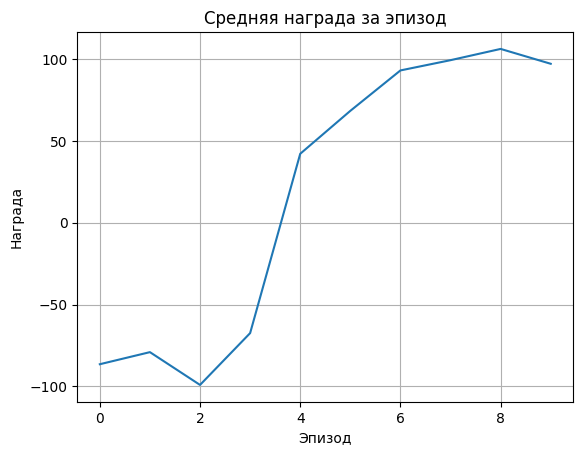

График для этапа 1 сохранен.
DataFrame для этапа 1 сохранен.
Episode 1, Avg Reward: 73.07
Episode 2, Avg Reward: 89.64
Episode 3, Avg Reward: 81.90
Episode 4, Avg Reward: 60.30
Episode 5, Avg Reward: 104.05
Episode 6, Avg Reward: 92.66
Episode 7, Avg Reward: 98.54
Episode 8, Avg Reward: 101.80
Episode 9, Avg Reward: 94.65
Episode 10, Avg Reward: 100.48
Episode 11, Avg Reward: 103.51
Episode 12, Avg Reward: 96.35
Episode 13, Avg Reward: 83.52
Episode 14, Avg Reward: 83.67
Episode 15, Avg Reward: 111.79
Episode 16, Avg Reward: 102.05
Episode 17, Avg Reward: 88.02
Episode 18, Avg Reward: 100.47
Episode 19, Avg Reward: 114.79
Episode 20, Avg Reward: 89.01


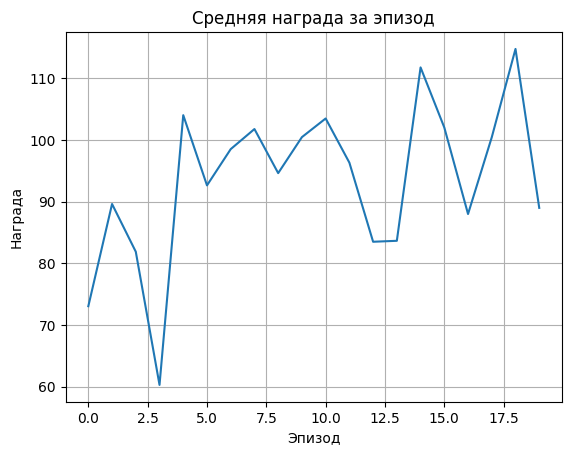

График для этапа 2 сохранен.
DataFrame для этапа 2 сохранен.
Episode 1, Avg Reward: 92.19
Episode 2, Avg Reward: 81.90
Episode 3, Avg Reward: 88.18
Episode 4, Avg Reward: 93.37
Episode 5, Avg Reward: 98.52
Episode 6, Avg Reward: 95.48
Episode 7, Avg Reward: 91.76
Episode 8, Avg Reward: 96.54
Episode 9, Avg Reward: 101.98
Episode 10, Avg Reward: 106.21
Episode 11, Avg Reward: 105.83
Episode 12, Avg Reward: 97.65
Episode 13, Avg Reward: 98.67
Episode 14, Avg Reward: 92.62
Episode 15, Avg Reward: 97.91
Episode 16, Avg Reward: 95.61
Episode 17, Avg Reward: 98.52
Episode 18, Avg Reward: 97.35
Episode 19, Avg Reward: 103.41
Episode 20, Avg Reward: 105.09


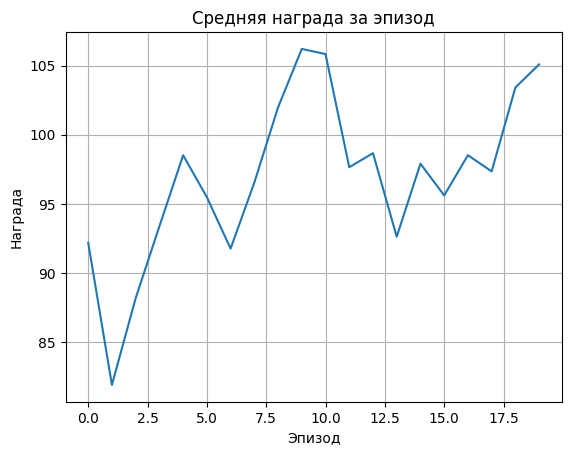

График для этапа 3 сохранен.
DataFrame для этапа 3 сохранен.


In [32]:
if __name__ == "__main__":
    # Этап 1: Базовое обучение 7 агентов
    stage1 = MADDPG()

    initial_states = stage1.env.states.copy()
    stage1.train()
    stage1.save_policies('stage1')
    stage1.plot_results()
    save_plot(stage=1)

    final_states = stage1.env.states.copy()
    df1 = create_dataframe(initial_states, final_states)
    save_dataframe(df1, stage=1)

    # Этап 2: Добавление 21 нового агента (всего 28)
    stage2 = MADDPG(num_regions=28, prev_agents=stage1.agents)

    initial_states2 = stage2.env.states.copy()
    stage2.train(episodes=20)
    stage2.save_policies('stage2')
    stage2.plot_results()
    save_plot(stage=2)

    final_states2 = stage2.env.states.copy()
    df2 = create_dataframe(initial_states2, final_states2)
    save_dataframe(df2, stage=2)

    # Этап 3: Добавление 61 нового агента (всего 89)
    stage3 = MADDPG(num_regions=89, prev_agents=stage2.agents)

    initial_states3 = stage3.env.states.copy()
    stage3.train(episodes=20)
    stage3.save_policies('stage3')
    stage3.plot_results()
    save_plot(stage=3)

    final_states3 = stage3.env.states.copy()
    df3 = create_dataframe(initial_states3, final_states3)
    save_dataframe(df3, stage=3)